# Malzbier Brahma — MACO Gerado: Análise dos 3 Cenários de Demanda

| Cenário | Descrição |
|---|---|
| **① Antes** | Cenário Divulgado — demanda original |
| **② Após +30%** | Nova Demanda bruta — aumento de 30% aplicado pelas GEOs |
| **③ Após BIAS −9%** | Nova Demanda ajustada — retira o BIAS histórico de superestimação |

> **MACO Líquido = Demanda atendida × R\$285/HL − Custo Frete externo**  
> Custo frete = transferência rodo W0 (15.103 HL chegada) × custo/HL ÷ 0,95 (avaria)  
> Proporção CDR: NE Sul → BA · Mapapi, NE Norte, NO Centro → PB

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Estilo ────────────────────────────────────────────────────────────────────
BG   = '#0f1117'; AX  = '#1a1d27'; GR  = '#2e3145'; TXT = '#e0e0e0'
C1   = '#4fc3f7'   # azul  — ① Antes
C2   = '#f06292'   # rosa  — ② Após +30%
C3   = '#ffb74d'   # amber — ③ Após BIAS −9%
CPOS = '#a5d6a7';  CNEG = '#ef9a9a'; CDOI = '#ffd54f'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': AX, 'axes.edgecolor': GR,
    'axes.labelcolor': TXT, 'xtick.color': '#b0b0b0', 'ytick.color': '#b0b0b0',
    'text.color': TXT, 'grid.color': GR, 'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 11, 'axes.labelsize': 10,
})

SEMANAS = ['W0', 'W1', 'W2', 'W3']
XTICK   = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
XP      = np.arange(4)
GEOS    = ['Mapapi', 'NE Norte', 'NE Sul', 'NO Araguaia', 'NO Centro']
CORES_GEO = ['#7986cb', '#4db6ac', '#ffb74d', '#e57373', '#ce93d8']

# ═══════════════════════════════════════════════════════════════════════════════
# DADOS — extraídos da planilha Analise_LongNeck_WSNP - Sem repostas.xlsb
# Aba: Cenário Divulgado | Cenário com Nova Demanda | Custos de transferência
# ═══════════════════════════════════════════════════════════════════════════════

# ── Demanda por GEO (HL) ─────────────────────────────────────  W0        W1        W2        W3
DEM_DIV_GEO = {
    'Mapapi':      np.array([4672.926,  4835.700,  3275.406,  4003.524]),
    'NE Norte':    np.array([1516.734,  1742.922,  1313.766,  1418.454]),
    'NE Sul':      np.array([2484.882,  2705.850,  1991.610,  2197.890]),
    'NO Araguaia': np.array([  60.660,    71.442,    48.402,    50.688]),
    'NO Centro':   np.array([1713.474,  1894.680,  1376.622,  1558.404]),
}
DEM_ND_GEO = {
    'Mapapi':      np.array([6074.8038, 6286.4100, 4258.0278, 5204.5812]),
    'NE Norte':    np.array([1971.7542, 2265.7986, 1707.8958, 1843.9902]),
    'NE Sul':      np.array([3230.3466, 3517.6050, 2589.0930, 2857.2570]),
    'NO Araguaia': np.array([  78.8580,   92.8746,   62.9226,   65.8944]),
    'NO Centro':   np.array([2227.5162, 2463.0840, 1789.6086, 2025.9252]),
}

# ── Demanda TOTAL NENO (HL) ───────────────────────────────────────────────────
DEM_DIV_TOT = np.array([10448.676,  11250.594,   8005.806,   9228.960])
DEM_ND_TOT  = np.array([13583.2788, 14625.7722, 10407.5478, 11997.6480])

# ── Estoque Final TOTAL NENO (HL) ─────────────────────────────────────────────
EF_DIV  = np.array([13386.9833, 11213.5623, 23780.1538, 14551.2811])
EF_ND   = np.array([10252.3805,  4626.7813, 14739.6310,  2742.0703])

# ── Suficiência Final TOTAL NENO (dias) ───────────────────────────────────────
SUF_DIV = np.array([ 7.139347,  8.404072, 15.460130,  9.460187])
SUF_ND  = np.array([ 4.205883,  2.667361,  7.371260,  1.371304])

# ── Estoque Inicial W0 TOTAL NENO (HL) ───────────────────────────────────────
EI_W0 = 7635.438

# ── SP — Fábrica (Jaguariúna): WSNP, EF e SUF ────────────────────────────────
WSNP_SP = np.array([ 7200.0, 17280.0,  3600.0, 13320.0])   # igual nos dois cenários
EF_SP   = np.array([19338.41, 19830.74, 6643.07,  4104.10])
EI_SP_W0 = 33738.26
SUF_SP   = np.array([18.3219, 18.7884,  7.3755,   4.5566])

# ── Trânsito TOTAL NENO (HL) ─────────────────────────────────────────────────
TRANSIT_DIV = np.array([0.0, 77.0, 52.0,  0.0])
TRANSIT_ND  = np.array([0.0,  0.0,  0.0,  0.0])

# ── Custos (R$/HL — cabotagem) ────────────────────────────────────────────────
CABO_BA = 84.579425   # Jaguariúna → CDR Camaçari (BA)
CABO_PB = 95.328283   # Jaguariúna → CDR João Pessoa (PB)
RODO_BA = CABO_BA * 1.6   # = 135.33 R$/HL
RODO_PB = CABO_PB * 1.6   # = 152.53 R$/HL
MACO_U  = 285.0            # R$/HL — MACO produção interna
CPROD   = 149.0            # R$/HL — custo de produção

# ── Parâmetros solução final ──────────────────────────────────────────────────
BIAS   = 1.09     # GEOs superestimam demanda em +9%
AVARIA = 0.95     # 5% de perda no transporte rodoviário
DOI_MIN = 12      # dias mínimos de cobertura

# Transferência rodo W0 — calculada na solução final
TRANSF_W0_CHEGADA = 15103.0    # HL chegando ao NENO
TRANSF_W0_EMB_BA  = 3803.0  / AVARIA   # 4003.2 HL embarcados BA
TRANSF_W0_EMB_PB  = 12095.0 / AVARIA   # 12731.6 HL embarcados PB
CUSTO_FRETE_TOTAL = TRANSF_W0_EMB_BA * RODO_BA + TRANSF_W0_EMB_PB * RODO_PB

# ── Derivações dos 3 cenários ─────────────────────────────────────────────────
DEM_BIAS_TOT    = DEM_ND_TOT  / BIAS
DEM_BIAS_GEO    = {geo: DEM_ND_GEO[geo] / BIAS for geo in GEOS}

MACO_BRUTO_DIV  = DEM_DIV_TOT.sum()  * MACO_U
MACO_BRUTO_ND   = DEM_ND_TOT.sum()   * MACO_U
MACO_BRUTO_BIAS = DEM_BIAS_TOT.sum() * MACO_U

MACO_LIQ_DIV    = MACO_BRUTO_DIV  - 0
MACO_LIQ_ND     = MACO_BRUTO_ND   - CUSTO_FRETE_TOTAL
MACO_LIQ_BIAS   = MACO_BRUTO_BIAS - CUSTO_FRETE_TOTAL

# ── Print resumo ──────────────────────────────────────────────────────────────
print("=" * 68)
print("MALZBIER BRAHMA — MACO GERADO NOS 3 CENÁRIOS")
print("=" * 68)
print(f"{'Cenário':<30} {'Dem. Total':>11} {'MACO Bruto':>14} {'Frete':>12} {'MACO Líquido':>14}")
print("-" * 68)
for lbl, dem, bruto, frete, liq in [
    ("① Antes (Divulgado)",      DEM_DIV_TOT.sum(),  MACO_BRUTO_DIV,  0,                  MACO_LIQ_DIV),
    ("② Após +30% (s/ BIAS)",    DEM_ND_TOT.sum(),   MACO_BRUTO_ND,   CUSTO_FRETE_TOTAL,  MACO_LIQ_ND),
    ("③ Após +30% c/ BIAS −9%",  DEM_BIAS_TOT.sum(), MACO_BRUTO_BIAS, CUSTO_FRETE_TOTAL,  MACO_LIQ_BIAS),
]:
    print(f"{lbl:<30} {dem:>10,.0f}HL  R${bruto:>12,.0f}  R${frete:>10,.0f}  R${liq:>12,.0f}")
print(f"\nCusto frete rodo W0: R$ {CUSTO_FRETE_TOTAL:,.0f}")
print(f"  BA: {TRANSF_W0_EMB_BA:,.0f} HL × R${RODO_BA:.2f}/HL = R$ {TRANSF_W0_EMB_BA*RODO_BA:,.0f}")
print(f"  PB: {TRANSF_W0_EMB_PB:,.0f} HL × R${RODO_PB:.2f}/HL = R$ {TRANSF_W0_EMB_PB*RODO_PB:,.0f}")


MALZBIER BRAHMA — MACO GERADO NOS 3 CENÁRIOS
Cenário                         Dem. Total     MACO Bruto        Frete   MACO Líquido
--------------------------------------------------------------------
① Antes (Divulgado)                38,934HL  R$  11,096,200  R$         0  R$  11,096,200
② Após +30% (s/ BIAS)              50,614HL  R$  14,425,060  R$ 2,483,623  R$  11,941,437
③ Após +30% c/ BIAS −9%            46,435HL  R$  13,234,000  R$ 2,483,623  R$  10,750,377

Custo frete rodo W0: R$ 2,483,623
  BA: 4,003 HL × R$135.33/HL = R$ 541,736
  PB: 12,732 HL × R$152.53/HL = R$ 1,941,887


---
## 1. Demanda — Comparativo dos 3 Cenários por Semana

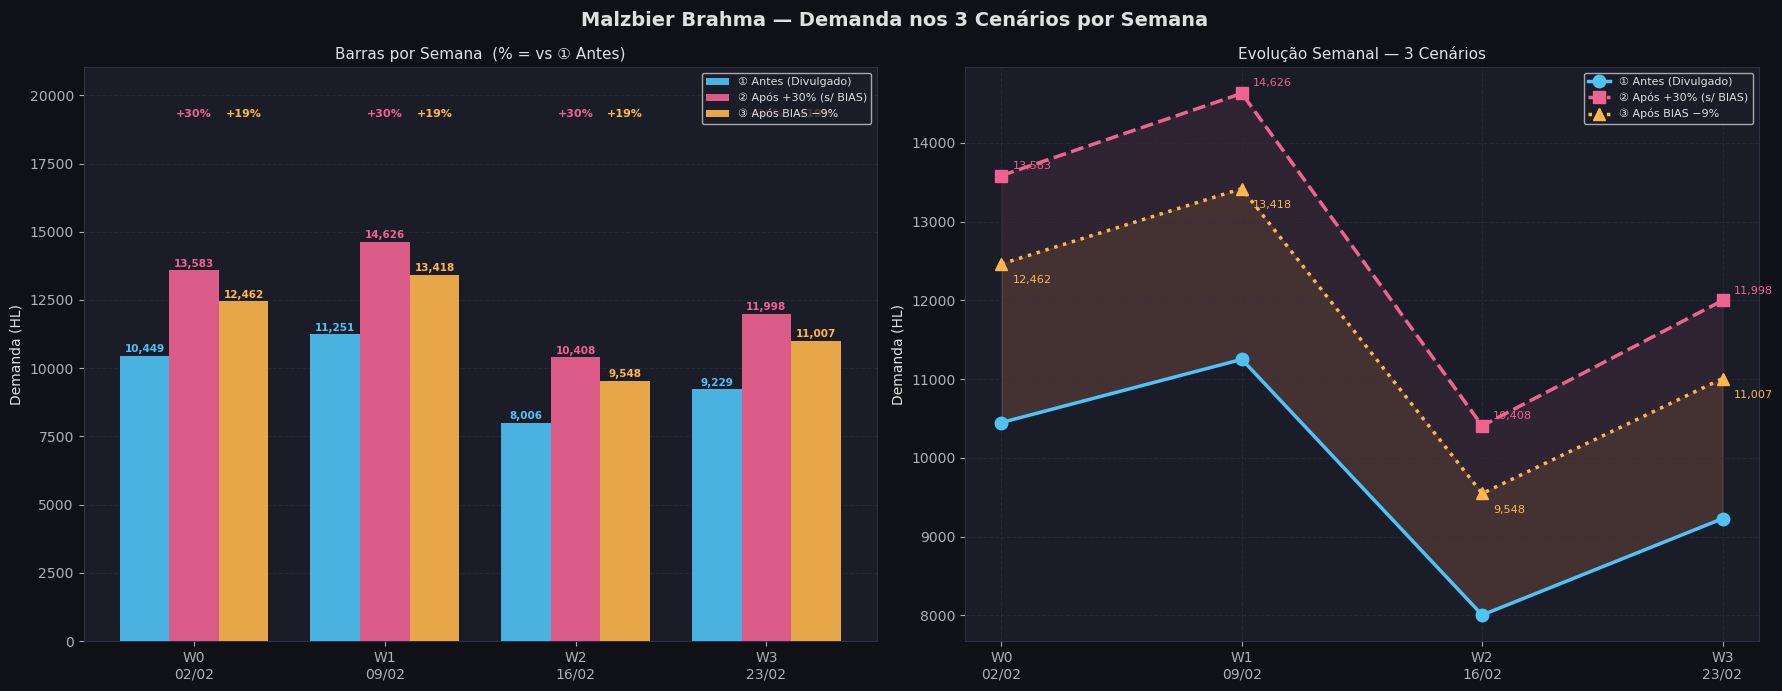


Semana    ① Antes   ② Após +30%   ③ BIAS −9%       Δ ②−①       Δ ③−①
--------------------------------------------------------------------
W0       10,448.7      13,583.3     12,461.7    +3,134.6    +2,013.0
W1       11,250.6      14,625.8     13,418.1    +3,375.2    +2,167.5
W2        8,005.8      10,407.5      9,548.2    +2,401.7    +1,542.4
W3        9,229.0      11,997.6     11,007.0    +2,768.7    +1,778.1
--------------------------------------------------------------------
TOTAL    38,934.0      50,614.2     46,435.1   +11,680.2    +7,501.1


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier Brahma — Demanda nos 3 Cenários por Semana', fontsize=14, fontweight='bold', color=TXT)

# ── Barras agrupadas ──────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(AX)
bw = 0.26
b1 = ax.bar(XP - bw, DEM_DIV_TOT,  bw, color=C1, alpha=0.9, label='① Antes (Divulgado)',    zorder=3)
b2 = ax.bar(XP,      DEM_ND_TOT,   bw, color=C2, alpha=0.9, label='② Após +30% (s/ BIAS)',  zorder=3)
b3 = ax.bar(XP + bw, DEM_BIAS_TOT, bw, color=C3, alpha=0.9, label='③ Após BIAS −9%',        zorder=3)

ymax = DEM_ND_TOT.max() * 1.25
for bars, vals, cor in [(b1,DEM_DIV_TOT,C1),(b2,DEM_ND_TOT,C2),(b3,DEM_BIAS_TOT,C3)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ymax*0.007,
                f'{v:,.0f}', ha='center', fontsize=7.5, color=cor, fontweight='bold')

for i in range(4):
    pct2 = (DEM_ND_TOT[i]   - DEM_DIV_TOT[i]) / DEM_DIV_TOT[i] * 100
    pct3 = (DEM_BIAS_TOT[i] - DEM_DIV_TOT[i]) / DEM_DIV_TOT[i] * 100
    ax.text(i,      ymax * 1.05, f'{pct2:+.0f}%', ha='center', fontsize=8, color=C2, fontweight='bold')
    ax.text(i + bw, ymax * 1.05, f'{pct3:+.0f}%', ha='center', fontsize=8, color=C3, fontweight='bold')

ax.set_xticks(XP); ax.set_xticklabels(XTICK)
ax.set_ylabel('Demanda (HL)'); ax.set_title('Barras por Semana  (% = vs ① Antes)')
ax.set_ylim(0, ymax * 1.15); ax.legend(fontsize=8); ax.grid(axis='y', zorder=0)

# ── Linha evolutiva ───────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(AX)
ax2.plot(XP, DEM_DIV_TOT,  'o-',  color=C1, lw=2.5, ms=9, label='① Antes (Divulgado)',   zorder=4)
ax2.plot(XP, DEM_ND_TOT,   's--', color=C2, lw=2.5, ms=9, label='② Após +30% (s/ BIAS)', zorder=4)
ax2.plot(XP, DEM_BIAS_TOT, '^:',  color=C3, lw=2.5, ms=9, label='③ Após BIAS −9%',       zorder=4)
ax2.fill_between(XP, DEM_DIV_TOT, DEM_ND_TOT,   alpha=0.10, color=C2)
ax2.fill_between(XP, DEM_DIV_TOT, DEM_BIAS_TOT, alpha=0.10, color=C3)

for i in range(4):
    ax2.annotate(f'{DEM_ND_TOT[i]:,.0f}',
                 xy=(i, DEM_ND_TOT[i]),   xytext=(8, 5),   textcoords='offset points', fontsize=8, color=C2)
    ax2.annotate(f'{DEM_BIAS_TOT[i]:,.0f}',
                 xy=(i, DEM_BIAS_TOT[i]), xytext=(8, -14), textcoords='offset points', fontsize=8, color=C3)

ax2.set_xticks(XP); ax2.set_xticklabels(XTICK)
ax2.set_ylabel('Demanda (HL)'); ax2.set_title('Evolução Semanal — 3 Cenários')
ax2.legend(fontsize=8); ax2.grid(zorder=0)

plt.tight_layout(); plt.show()

print(f"\n{'Semana':<6} {'① Antes':>10} {'② Após +30%':>13} {'③ BIAS −9%':>12}  {'Δ ②−①':>10}  {'Δ ③−①':>10}")
print("-" * 68)
for i, w in enumerate(SEMANAS):
    print(f"{w:<6} {DEM_DIV_TOT[i]:>10,.1f} {DEM_ND_TOT[i]:>13,.1f} {DEM_BIAS_TOT[i]:>12,.1f}"
          f"  {DEM_ND_TOT[i]-DEM_DIV_TOT[i]:>+10,.1f}  {DEM_BIAS_TOT[i]-DEM_DIV_TOT[i]:>+10,.1f}")
print("-" * 68)
print(f"{'TOTAL':<6} {DEM_DIV_TOT.sum():>10,.1f} {DEM_ND_TOT.sum():>13,.1f} {DEM_BIAS_TOT.sum():>12,.1f}"
      f"  {DEM_ND_TOT.sum()-DEM_DIV_TOT.sum():>+10,.1f}  {DEM_BIAS_TOT.sum()-DEM_DIV_TOT.sum():>+10,.1f}")


---
## 2. Demanda por GEO — Distribuição Regional nos 3 Cenários

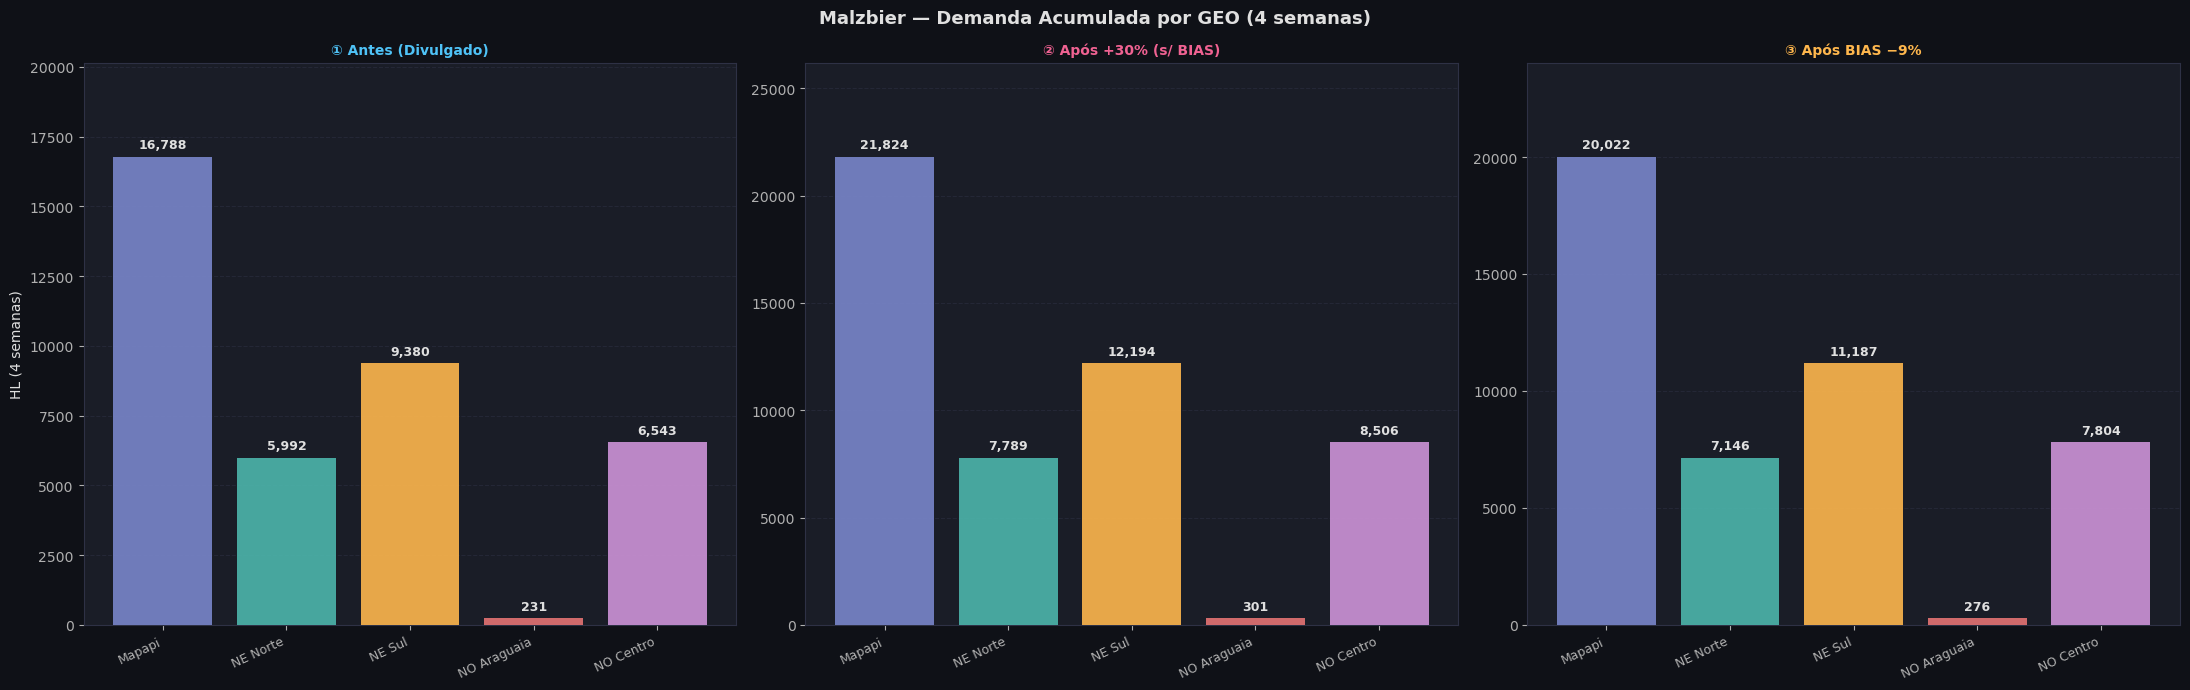

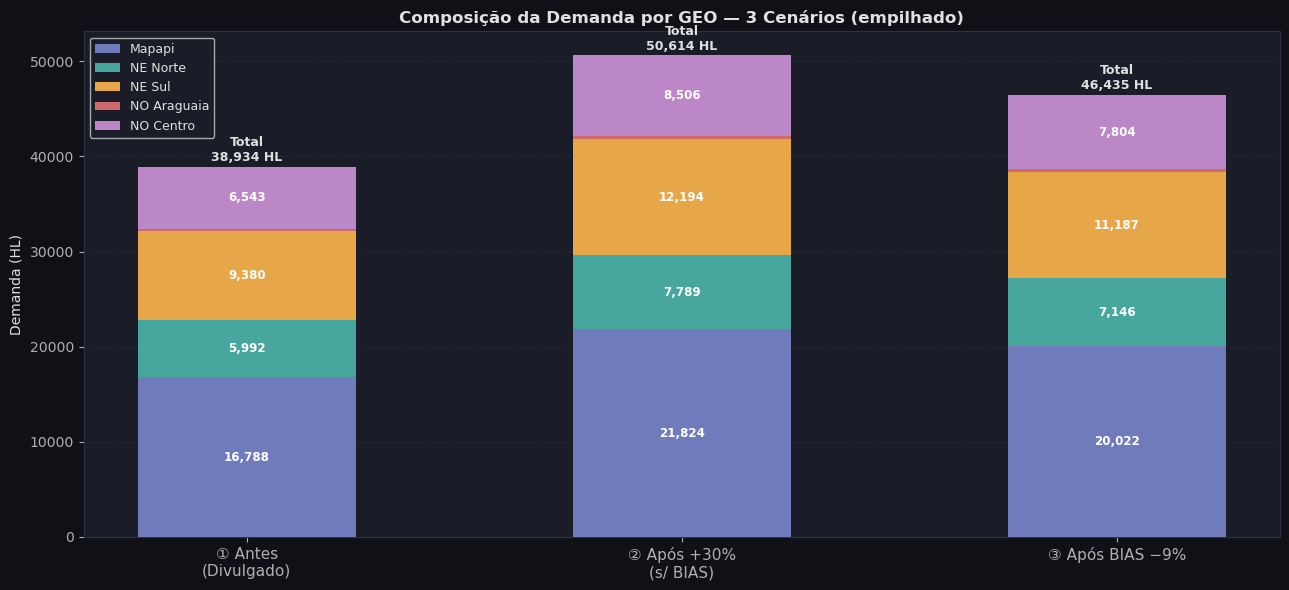

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier — Demanda Acumulada por GEO (4 semanas)', fontsize=13, fontweight='bold', color=TXT)

for ax_i, (titulo, geo_data, cor) in enumerate([
    ('① Antes (Divulgado)',   DEM_DIV_GEO,  C1),
    ('② Após +30% (s/ BIAS)', DEM_ND_GEO,   C2),
    ('③ Após BIAS −9%',       DEM_BIAS_GEO, C3),
]):
    ax = axes[ax_i]
    ax.set_facecolor(AX)
    totais = [geo_data[g].sum() for g in GEOS]
    bars   = ax.bar(GEOS, totais, color=CORES_GEO, alpha=0.9, zorder=3)
    ymax   = max(totais) * 1.2
    for bar, v in zip(bars, totais):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ymax*0.015,
                f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold', color=TXT)
    ax.set_xticklabels(GEOS, rotation=25, ha='right', fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight='bold', color=cor)
    ax.set_ylabel('HL (4 semanas)' if ax_i == 0 else '')
    ax.set_ylim(0, ymax); ax.grid(axis='y', zorder=0)

plt.tight_layout(); plt.show()

# ── Stacked bar comparativo ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(AX)
ax.set_title('Composição da Demanda por GEO — 3 Cenários (empilhado)', fontsize=12, fontweight='bold')

xp3 = np.arange(3)
bottom = np.zeros(3)
all_geo_data = [DEM_DIV_GEO, DEM_ND_GEO, DEM_BIAS_GEO]
for geo, cor in zip(GEOS, CORES_GEO):
    vals = np.array([d[geo].sum() for d in all_geo_data])
    ax.bar(xp3, vals, 0.5, bottom=bottom, color=cor, alpha=0.9, label=geo, zorder=3)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 600:
            ax.text(xi, b + v/2, f'{v:,.0f}', ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
    bottom += vals

for xi, tot in enumerate(bottom):
    ax.text(xi, tot + bottom.max()*0.012, f'Total\n{tot:,.0f} HL',
            ha='center', fontsize=9, fontweight='bold', color=TXT)

ax.set_xticks(xp3)
ax.set_xticklabels(['① Antes\n(Divulgado)', '② Após +30%\n(s/ BIAS)', '③ Após BIAS −9%\n'], fontsize=11)
ax.set_ylabel('Demanda (HL)'); ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', zorder=0); plt.tight_layout(); plt.show()


---
## 3. MACO Gerado — Waterfall por Cenário

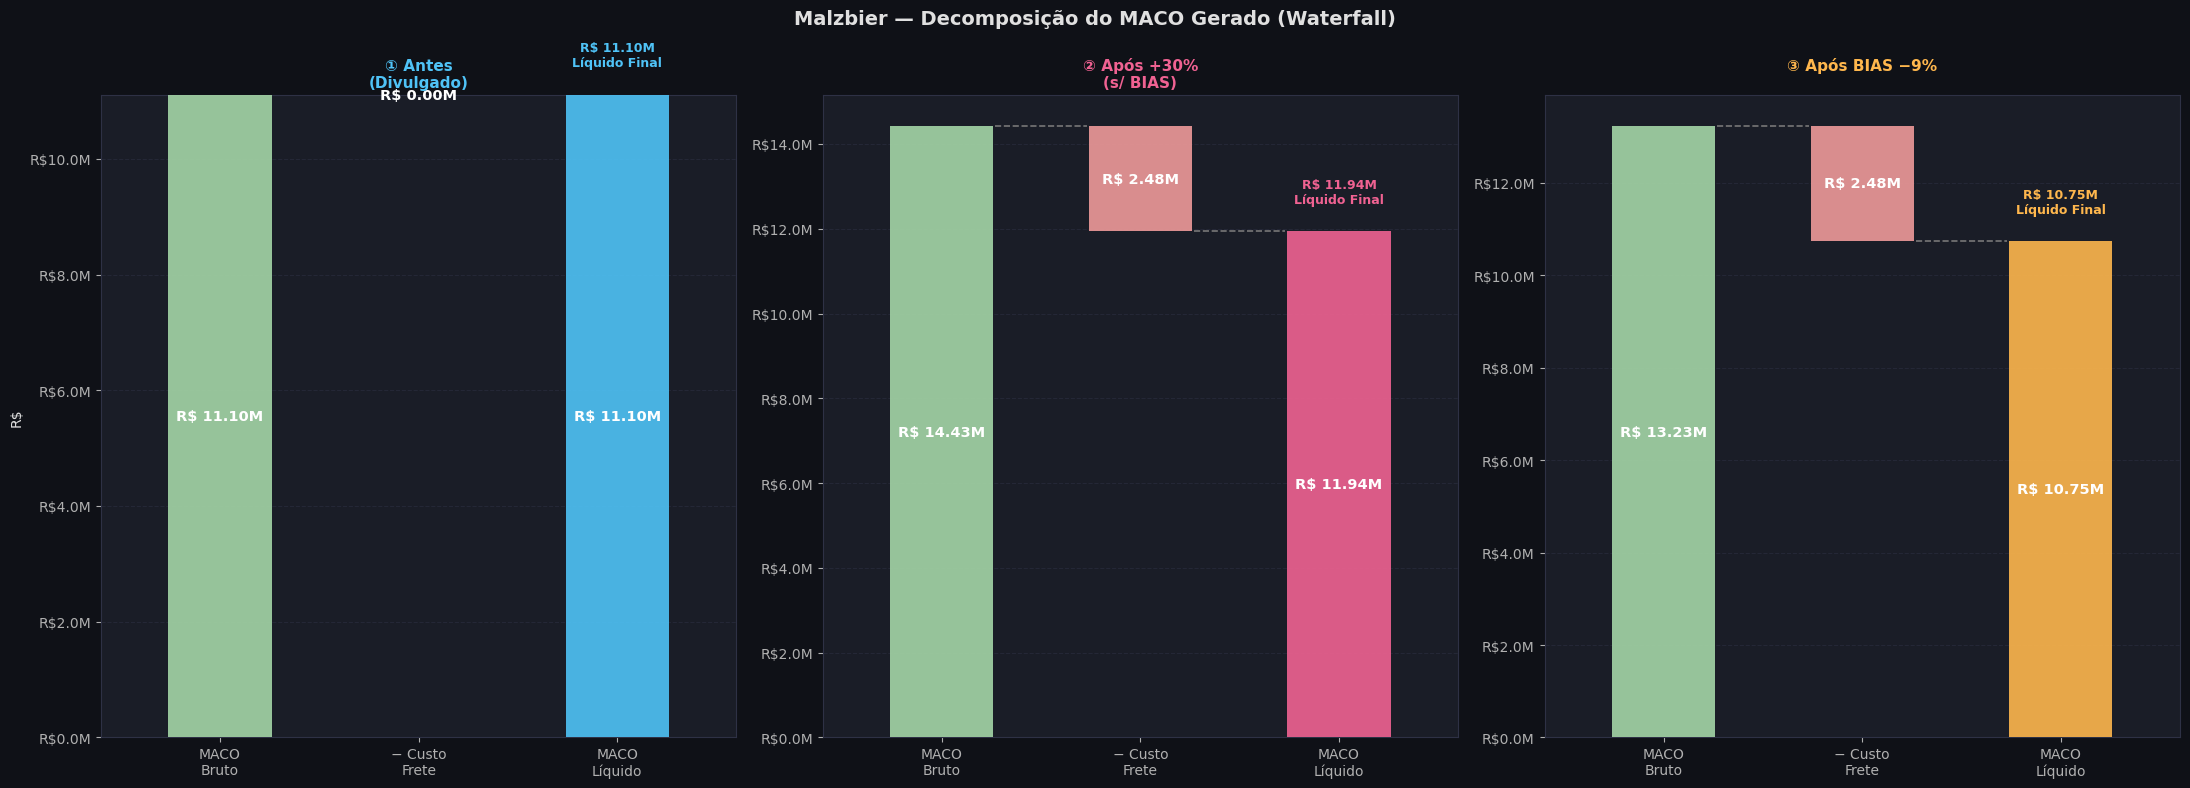

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier — Decomposição do MACO Gerado (Waterfall)', fontsize=14, fontweight='bold', color=TXT)

for ax_i, (titulo, bruto, frete, liq, cor) in enumerate([
    ('① Antes\n(Divulgado)',    MACO_BRUTO_DIV,  0,                  MACO_LIQ_DIV,  C1),
    ('② Após +30%\n(s/ BIAS)', MACO_BRUTO_ND,   CUSTO_FRETE_TOTAL,  MACO_LIQ_ND,   C2),
    ('③ Após BIAS −9%\n',      MACO_BRUTO_BIAS, CUSTO_FRETE_TOTAL,  MACO_LIQ_BIAS, C3),
]):
    ax = axes[ax_i]
    ax.set_facecolor(AX)

    cats   = ['MACO\nBruto', '− Custo\nFrete', 'MACO\nLíquido']
    vals   = [bruto, -frete, liq]
    bases  = [0,     bruto,  0]
    cbars  = [CPOS,  CNEG,   cor]

    for xi, (cat, val, base, cb) in enumerate(zip(cats, vals, bases, cbars)):
        h = abs(val)
        bot = base if val >= 0 else base + val
        ax.bar(xi, h, 0.52, bottom=bot, color=cb, alpha=0.9, zorder=3)
        mid = bot + h/2
        ax.text(xi, mid, f'R$ {abs(val)/1e6:.2f}M', ha='center', va='center',
                fontsize=10.5, fontweight='bold', color='white')
        if xi < 2 and val != 0:
            nxt = base + val
            ax.plot([xi+0.27, xi+0.73], [nxt, nxt], color='#777', lw=1.2, ls='--')

    ymax_w = bruto * 1.15
    ax.text(2, liq + ymax_w*0.04, f'R$ {liq/1e6:.2f}M\nLíquido Final',
            ha='center', fontsize=9, color=cor, fontweight='bold')
    ax.set_xticks([0,1,2]); ax.set_xticklabels(cats, fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold', color=cor)
    ax.set_ylabel('R$' if ax_i == 0 else '')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))
    ax.set_xlim(-0.6, 2.6); ax.grid(axis='y', zorder=0)

plt.tight_layout(); plt.show()


---
## 4. MACO Líquido Final — Painel Comparativo Central

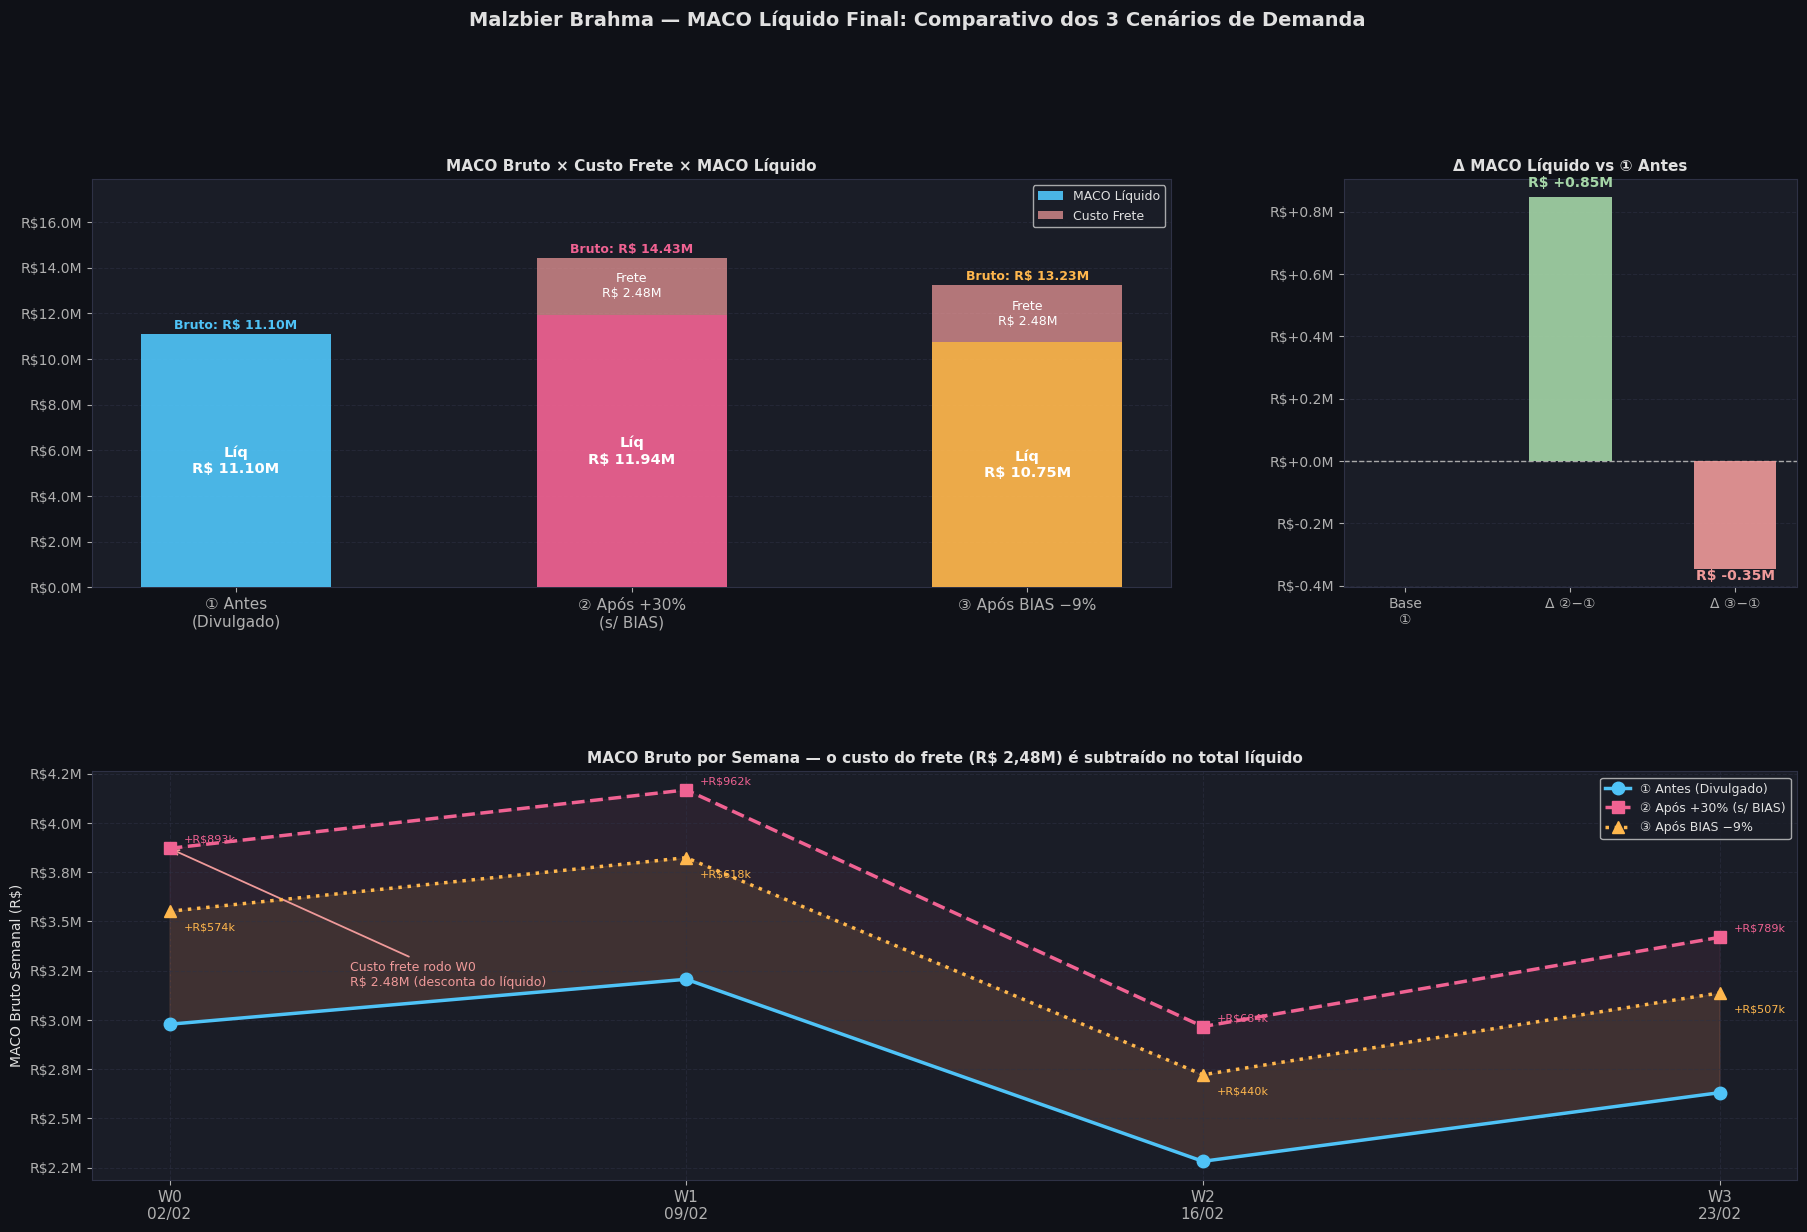

In [5]:
fig = plt.figure(figsize=(22, 13))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

BRUTOS = [MACO_BRUTO_DIV,  MACO_BRUTO_ND,   MACO_BRUTO_BIAS]
FRETES = [0,               CUSTO_FRETE_TOTAL, CUSTO_FRETE_TOTAL]
LIQS   = [MACO_LIQ_DIV,   MACO_LIQ_ND,     MACO_LIQ_BIAS]
CORS3  = [C1, C2, C3]
LABS3  = ['① Antes\n(Divulgado)', '② Após +30%\n(s/ BIAS)', '③ Após BIAS −9%\n']
xp3    = np.arange(3)

# ── A: MACO Bruto + Frete empilhado ──────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
ax_a.set_facecolor(AX)
ax_a.bar(xp3, LIQS,   0.48, color=CORS3, alpha=0.92, label='MACO Líquido', zorder=3)
ax_a.bar(xp3, FRETES, 0.48, bottom=LIQS, color=CNEG, alpha=0.72, label='Custo Frete',  zorder=3)

ymax_a = max(BRUTOS) * 1.24
for xi, (bruto, frete, liq, cor) in enumerate(zip(BRUTOS, FRETES, LIQS, CORS3)):
    ax_a.text(xi, bruto + ymax_a*0.013, f'Bruto: R$ {bruto/1e6:.2f}M',
              ha='center', fontsize=9, color=cor, fontweight='bold')
    ax_a.text(xi, liq/2, f'Líq\nR$ {liq/1e6:.2f}M',
              ha='center', va='center', fontsize=10.5, color='white', fontweight='bold')
    if frete > 0:
        ax_a.text(xi, liq + frete/2, f'Frete\nR$ {frete/1e6:.2f}M',
                  ha='center', va='center', fontsize=9, color='white')

ax_a.set_xticks(xp3); ax_a.set_xticklabels(LABS3, fontsize=11)
ax_a.set_title('MACO Bruto × Custo Frete × MACO Líquido', fontsize=11, fontweight='bold')
ax_a.set_ylim(0, ymax_a)
ax_a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))
ax_a.legend(fontsize=9); ax_a.grid(axis='y', zorder=0)

# ── B: Delta vs Base ─────────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
ax_b.set_facecolor(AX)
deltas = [0, LIQS[1]-LIQS[0], LIQS[2]-LIQS[0]]
dcors  = [TXT, CPOS if deltas[1]>=0 else CNEG, CPOS if deltas[2]>=0 else CNEG]
ax_b.bar(xp3, deltas, 0.5, color=dcors, alpha=0.9, zorder=3)
ax_b.axhline(0, color='#aaa', lw=1, ls='--')
mx = max(abs(d) for d in deltas) or 1
for xi, (v, c) in enumerate(zip(deltas, dcors)):
    if v != 0:
        ax_b.text(xi, v + mx*0.04*(1 if v>=0 else -1),
                  f'R$ {v/1e6:+.2f}M', ha='center', fontsize=10, fontweight='bold', color=c)
ax_b.set_xticks(xp3); ax_b.set_xticklabels(['Base\n①', 'Δ ②−①', 'Δ ③−①'], fontsize=10)
ax_b.set_title('Δ MACO Líquido vs ① Antes', fontsize=11, fontweight='bold')
ax_b.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'R${x/1e6:+.1f}M'))
ax_b.grid(axis='y', zorder=0)

# ── C: Evolução semanal MACO bruto ───────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, :])
ax_c.set_facecolor(AX)
ms_div  = DEM_DIV_TOT  * MACO_U
ms_nd   = DEM_ND_TOT   * MACO_U
ms_bias = DEM_BIAS_TOT * MACO_U

ax_c.plot(XP, ms_div,  'o-',  color=C1, lw=2.5, ms=9, label='① Antes (Divulgado)',   zorder=4)
ax_c.plot(XP, ms_nd,   's--', color=C2, lw=2.5, ms=9, label='② Após +30% (s/ BIAS)', zorder=4)
ax_c.plot(XP, ms_bias, '^:',  color=C3, lw=2.5, ms=9, label='③ Após BIAS −9%',       zorder=4)
ax_c.fill_between(XP, ms_div, ms_nd,   alpha=0.08, color=C2)
ax_c.fill_between(XP, ms_div, ms_bias, alpha=0.10, color=C3)

for i in range(4):
    d2 = ms_nd[i]   - ms_div[i]
    d3 = ms_bias[i] - ms_div[i]
    ax_c.annotate(f'+R${d2/1e3:.0f}k', xy=(i, ms_nd[i]),
                  xytext=(10, 4),   textcoords='offset points', fontsize=8, color=C2)
    ax_c.annotate(f'+R${d3/1e3:.0f}k', xy=(i, ms_bias[i]),
                  xytext=(10, -14), textcoords='offset points', fontsize=8, color=C3)

# Marca o custo do frete no W0
ax_c.annotate(
    f'Custo frete rodo W0\nR$ {CUSTO_FRETE_TOTAL/1e6:.2f}M (desconta do líquido)',
    xy=(0, ms_nd[0]), xytext=(0.35, ms_nd[0]*0.82),
    fontsize=9, color=CNEG,
    arrowprops=dict(arrowstyle='->', color=CNEG, lw=1.3))

ax_c.set_xticks(XP); ax_c.set_xticklabels(XTICK, fontsize=11)
ax_c.set_ylabel('MACO Bruto Semanal (R$)')
ax_c.set_title('MACO Bruto por Semana — o custo do frete (R$ 2,48M) é subtraído no total líquido', fontsize=11, fontweight='bold')
ax_c.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))
ax_c.legend(fontsize=9); ax_c.grid(zorder=0)

fig.suptitle('Malzbier Brahma — MACO Líquido Final: Comparativo dos 3 Cenários de Demanda',
             fontsize=14, fontweight='bold', color=TXT, y=1.01)
plt.tight_layout(); plt.show()


---
## 5. DOI × MACO — Risco vs Retorno por Semana

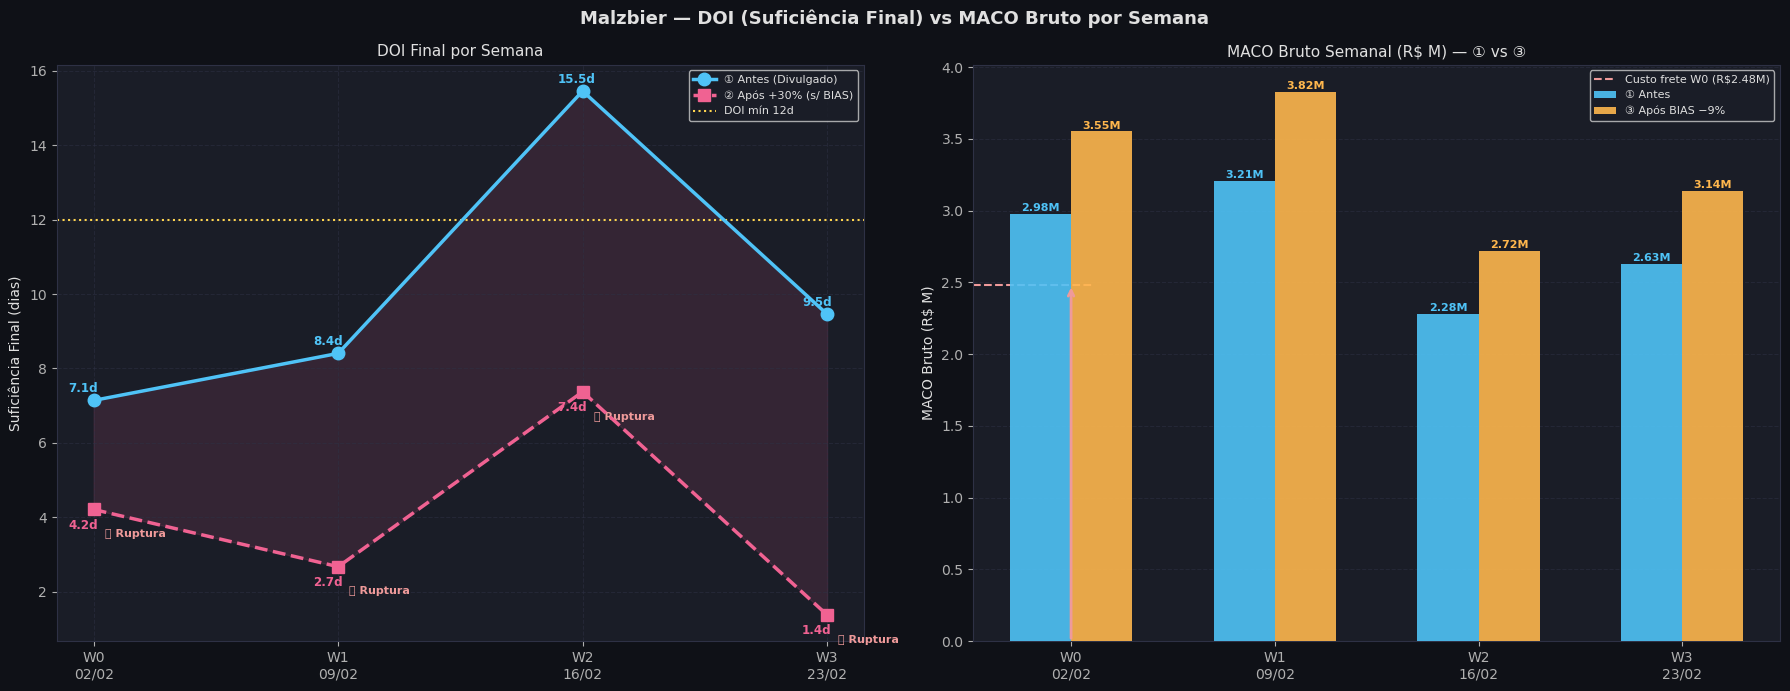

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier — DOI (Suficiência Final) vs MACO Bruto por Semana', fontsize=13, fontweight='bold', color=TXT)

# ── DOI Antes vs Nova Demanda ─────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(AX)
ax.plot(XP, SUF_DIV, 'o-',  color=C1, lw=2.5, ms=9, label='① Antes (Divulgado)',   zorder=4)
ax.plot(XP, SUF_ND,  's--', color=C2, lw=2.5, ms=9, label='② Após +30% (s/ BIAS)', zorder=4)
ax.fill_between(XP, SUF_DIV, SUF_ND, alpha=0.12, color=C2)
ax.axhline(DOI_MIN, color=CDOI, lw=1.5, ls=':', label=f'DOI mín {DOI_MIN}d')

for i in range(4):
    ax.annotate(f'{SUF_DIV[i]:.1f}d', xy=(i, SUF_DIV[i]), xytext=(-18, 6),
                textcoords='offset points', fontsize=8.5, color=C1, fontweight='bold')
    ax.annotate(f'{SUF_ND[i]:.1f}d',  xy=(i, SUF_ND[i]),  xytext=(-18,-14),
                textcoords='offset points', fontsize=8.5, color=C2, fontweight='bold')

# Marca rupturas
for i, v in enumerate(SUF_ND):
    if v < DOI_MIN:
        ax.annotate('🚨 Ruptura', xy=(i, v), xytext=(8, -20),
                    textcoords='offset points', fontsize=8, color=CNEG, fontweight='bold')

ax.set_xticks(XP); ax.set_xticklabels(XTICK)
ax.set_ylabel('Suficiência Final (dias)'); ax.set_title('DOI Final por Semana')
ax.legend(fontsize=8); ax.grid(zorder=0)

# ── MACO bruto semanal vs custo frete ────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(AX)
bw = 0.3
ax2.bar(XP - bw/2, DEM_DIV_TOT*MACO_U/1e6,  bw, color=C1, alpha=0.9, label='① Antes', zorder=3)
ax2.bar(XP + bw/2, DEM_BIAS_TOT*MACO_U/1e6, bw, color=C3, alpha=0.9, label='③ Após BIAS −9%', zorder=3)

# linha do custo do frete (concentrado em W0)
ax2.annotate('', xy=(0, CUSTO_FRETE_TOTAL/1e6), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color=CNEG, lw=2))
ax2.axhline(CUSTO_FRETE_TOTAL/1e6, xmax=0.15, color=CNEG, lw=1.5, ls='--', label=f'Custo frete W0 (R${CUSTO_FRETE_TOTAL/1e6:.2f}M)')

for i in range(4):
    v1 = DEM_DIV_TOT[i]*MACO_U/1e6
    v3 = DEM_BIAS_TOT[i]*MACO_U/1e6
    ax2.text(i-bw/2, v1+0.02, f'{v1:.2f}M', ha='center', fontsize=8, color=C1, fontweight='bold')
    ax2.text(i+bw/2, v3+0.02, f'{v3:.2f}M', ha='center', fontsize=8, color=C3, fontweight='bold')

ax2.set_xticks(XP); ax2.set_xticklabels(XTICK)
ax2.set_ylabel('MACO Bruto (R$ M)'); ax2.set_title('MACO Bruto Semanal (R$ M) — ① vs ③')
ax2.legend(fontsize=8); ax2.grid(axis='y', zorder=0)

plt.tight_layout(); plt.show()


---
## 6. Custo de Frete — Detalhamento por CDR

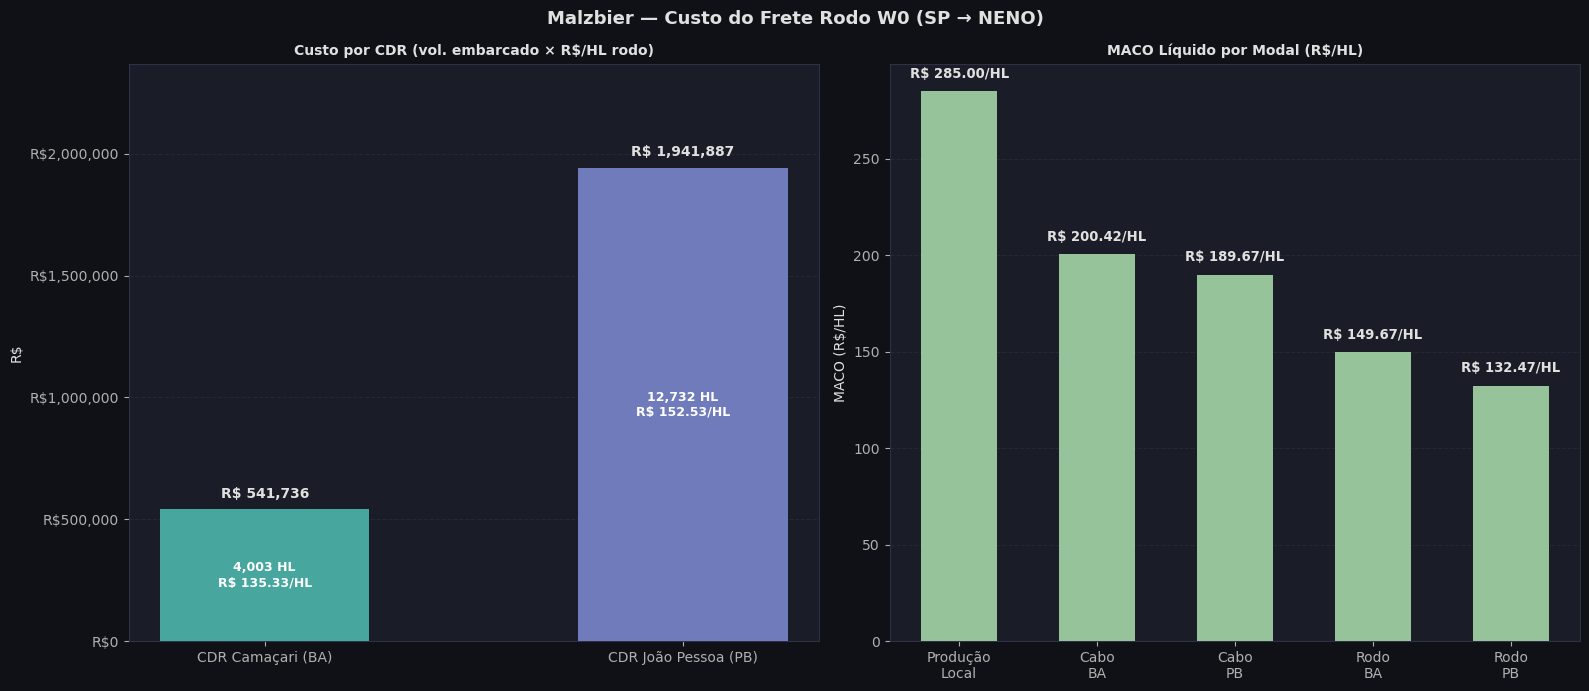


=== DETALHAMENTO CUSTO FRETE ===
  BA: 4,003.2 HL × R$135.33/HL = R$ 541,736
  PB: 12,731.6 HL × R$152.53/HL = R$ 1,941,887
  TOTAL:                             R$ 2,483,623
  (avaria 5% embutida: 15,898 HL chegam de 16,735 HL embarcados)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier — Custo do Frete Rodo W0 (SP → NENO)', fontsize=13, fontweight='bold', color=TXT)

# ── CDR breakdown ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(AX)
cdrs      = ['CDR Camaçari (BA)', 'CDR João Pessoa (PB)']
vols_emb  = [TRANSF_W0_EMB_BA,   TRANSF_W0_EMB_PB]
custos_u  = [RODO_BA,             RODO_PB]
custos_t  = [v*c for v,c in zip(vols_emb, custos_u)]
cores_cdr = ['#4db6ac', '#7986cb']

bars = ax.bar(cdrs, custos_t, 0.5, color=cores_cdr, alpha=0.9, zorder=3)
ymax_c = max(custos_t)*1.22
for bar, v, vol, cu in zip(bars, custos_t, vols_emb, custos_u):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ymax_c*0.02,
            f'R$ {v:,.0f}', ha='center', fontsize=10, fontweight='bold', color=TXT)
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2,
            f'{vol:,.0f} HL\nR$ {cu:.2f}/HL', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')

ax.set_title('Custo por CDR (vol. embarcado × R$/HL rodo)', fontsize=10, fontweight='bold')
ax.set_ylabel('R$'); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'R${x:,.0f}'))
ax.set_ylim(0, ymax_c); ax.grid(axis='y', zorder=0)

# ── MACO líquido por modal ────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(AX)
modais  = ['Produção\nLocal', 'Cabo\nBA', 'Cabo\nPB', 'Rodo\nBA', 'Rodo\nPB']
macols  = [MACO_U, MACO_U-CABO_BA, MACO_U-CABO_PB, MACO_U-RODO_BA, MACO_U-RODO_PB]
cores_m = [CPOS if v >= 0 else CNEG for v in macols]
bars2   = ax2.bar(modais, macols, 0.55, color=cores_m, alpha=0.9, zorder=3)
ax2.axhline(0, color='#888', lw=0.8, ls=':')
mx_m = max(macols)
for bar, v in zip(bars2, macols):
    yt = bar.get_height() + mx_m*0.025 if v >= 0 else bar.get_height() - mx_m*0.06
    ax2.text(bar.get_x()+bar.get_width()/2, yt,
             f'R$ {v:.2f}/HL', ha='center', fontsize=9.5, fontweight='bold', color=TXT)
ax2.set_title('MACO Líquido por Modal (R$/HL)', fontsize=10, fontweight='bold')
ax2.set_ylabel('MACO (R$/HL)'); ax2.grid(axis='y', zorder=0)

plt.tight_layout(); plt.show()

print(f"\n=== DETALHAMENTO CUSTO FRETE ===")
print(f"  BA: {TRANSF_W0_EMB_BA:,.1f} HL × R${RODO_BA:.2f}/HL = R$ {TRANSF_W0_EMB_BA*RODO_BA:,.0f}")
print(f"  PB: {TRANSF_W0_EMB_PB:,.1f} HL × R${RODO_PB:.2f}/HL = R$ {TRANSF_W0_EMB_PB*RODO_PB:,.0f}")
print(f"  TOTAL:                             R$ {CUSTO_FRETE_TOTAL:,.0f}")
print(f"  (avaria 5% embutida: {(TRANSF_W0_EMB_BA+TRANSF_W0_EMB_PB)*AVARIA:,.0f} HL chegam de {TRANSF_W0_EMB_BA+TRANSF_W0_EMB_PB:,.0f} HL embarcados)")
